In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

plt.rcParams.update({
    "figure.dpi": 600,
    "figure.figsize": (6, 2.5),
    "font.size": 8,
    "mathtext.fontset": "stix"
})

In [10]:

# Load vmem simulation data
base_dir = '/home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/sim_results/'
all_cell_models_folder = '/home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/all_cells_folder/'
cell_names = os.listdir(all_cell_models_folder)
print(len(cell_names))
vmem_amp_file_paths = [
    os.path.join(base_dir, f'vmem_amp_data_neo_Ez_{cell_name}.npy')
    for cell_name in cell_names
]

vmem_amp_data_list = [
    np.load(path, allow_pickle=True).item()
    for path in vmem_amp_file_paths
]
vmem_amp_data = {}
for data in vmem_amp_data_list:
    vmem_amp_data.update(data)


# --- Add asymmetry_factor to each cell ---
for cell_name, cell_data in vmem_amp_data.items():
    upper = cell_data.get('upper_z_endpoint')
    bottom = cell_data.get('bottom_z_endpoint')

    # Avoid division by zero or missing values
    if upper is not None and bottom is not None and (upper + bottom) != 0:
        asym_factor = np.abs(np.abs(upper) - np.abs(bottom)) / (np.abs(upper) + np.abs(bottom))
    else:
        asym_factor = np.nan  # use NaN for missing or invalid data

    cell_data['asymmetry_factor'] = asym_factor



1035


In [13]:
def box_plot_morph_properties(sim_data, properties, prop_names): 
    """Loads properties stored during simulation. 
    Plot variation in different neuron-types and print averages in notebook output."""
    
    data = {prop: {'PC': [], 'SS': [], 'Inhibitory': []} for prop in properties}
    
    # Organize data
    for cell, values in sim_data.items():

        for prop in properties:
            if 'PC' in cell or 'SP' in cell:
                data[prop]['PC'].append(values[prop])
            elif 'SS' in cell:
                data[prop]['SS'].append(values[prop])
            else:
                data[prop]['Inhibitory'].append(values[prop])
    
    # Prepare figure
    num_plots = len(properties)
    rows = (num_plots + 2) // 3  
    cols = 3 
    fig, axes = plt.subplots(rows, cols, figsize=(5, 2 * rows))
    axes = axes.flatten() 

    colors = {'PC': 'tab:green', 'SS': 'tab:purple', 'Inhibitory': 'tab:orange'}

    # Collect averages for printing
    table_data = []

    for i, prop in enumerate(properties):
        ax = axes[i]
        box = ax.boxplot(
            [data[prop]['PC'], data[prop]['SS'], data[prop]['Inhibitory']], 
            patch_artist=False,
            vert=True,
            showmeans=True,
            meanprops={"marker": "_", "markersize": 3, "markerfacecolor": "black", "markeredgecolor": "black"}
        )
        
        # Set colors
        for idx, (key, color) in enumerate(colors.items(), start=1):
            plt.setp(box['boxes'][idx-1], color=color, linewidth=1.5)
            plt.setp(box['whiskers'][2*(idx-1):2*idx], color=color)
            plt.setp(box['caps'][2*(idx-1):2*idx], color=color)
            plt.setp(box['medians'][idx-1], color=color)
            plt.setp(box['fliers'][idx-1], marker='o', markersize=3, alpha=0.7, 
                     markerfacecolor=color, markeredgecolor=color)

        ax.set_xticklabels(['Pyr', 'SS', 'Inhb'])
        if prop == 'symmetry_factor' or prop == 'number_of_soma_dendrites':
            ax.set_ylabel(prop_names[prop])
        else:
            ax.set_ylabel(f'{prop_names[prop]} [µm]')
        ax.grid(axis='both', linestyle='--', alpha=0.5, color='gray', linewidth=0.5)

        # Compute averages
        means = {
            "Property": prop_names[prop],
            "Pyramidal mean": np.mean(data[prop]['PC']) if data[prop]['PC'] else np.nan,
            "Pyramidal median": np.median(data[prop]['PC']) if data[prop]['PC'] else np.nan,
            #"Spiny Stellate": np.mean(data[prop]['SS']) if data[prop]['SS'] else np.nan,
            "Inhibitory mean": np.mean(data[prop]['Inhibitory']) if data[prop]['Inhibitory'] else np.nan,
            "Inhibitory median": np.median(data[prop]['Inhibitory']) if data[prop]['Inhibitory'] else np.nan
        }
        table_data.append(means)

    letters = 'ABCDEF'
    for idx, ax in enumerate(axes):
        ax.text(-0.15, 1.1, letters[idx], transform=ax.transAxes, fontsize=10, fontweight='bold')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.savefig('/home/tone/work/celltype_ES/CellTypeDependenceElStim/notebooks/fig2.pdf',
                bbox_inches="tight")
    plt.show()

    # Print summary table in notebook
    df = pd.DataFrame(table_data)
    pd.set_option("display.precision", 2)  # 2 decimal places
    display(df)


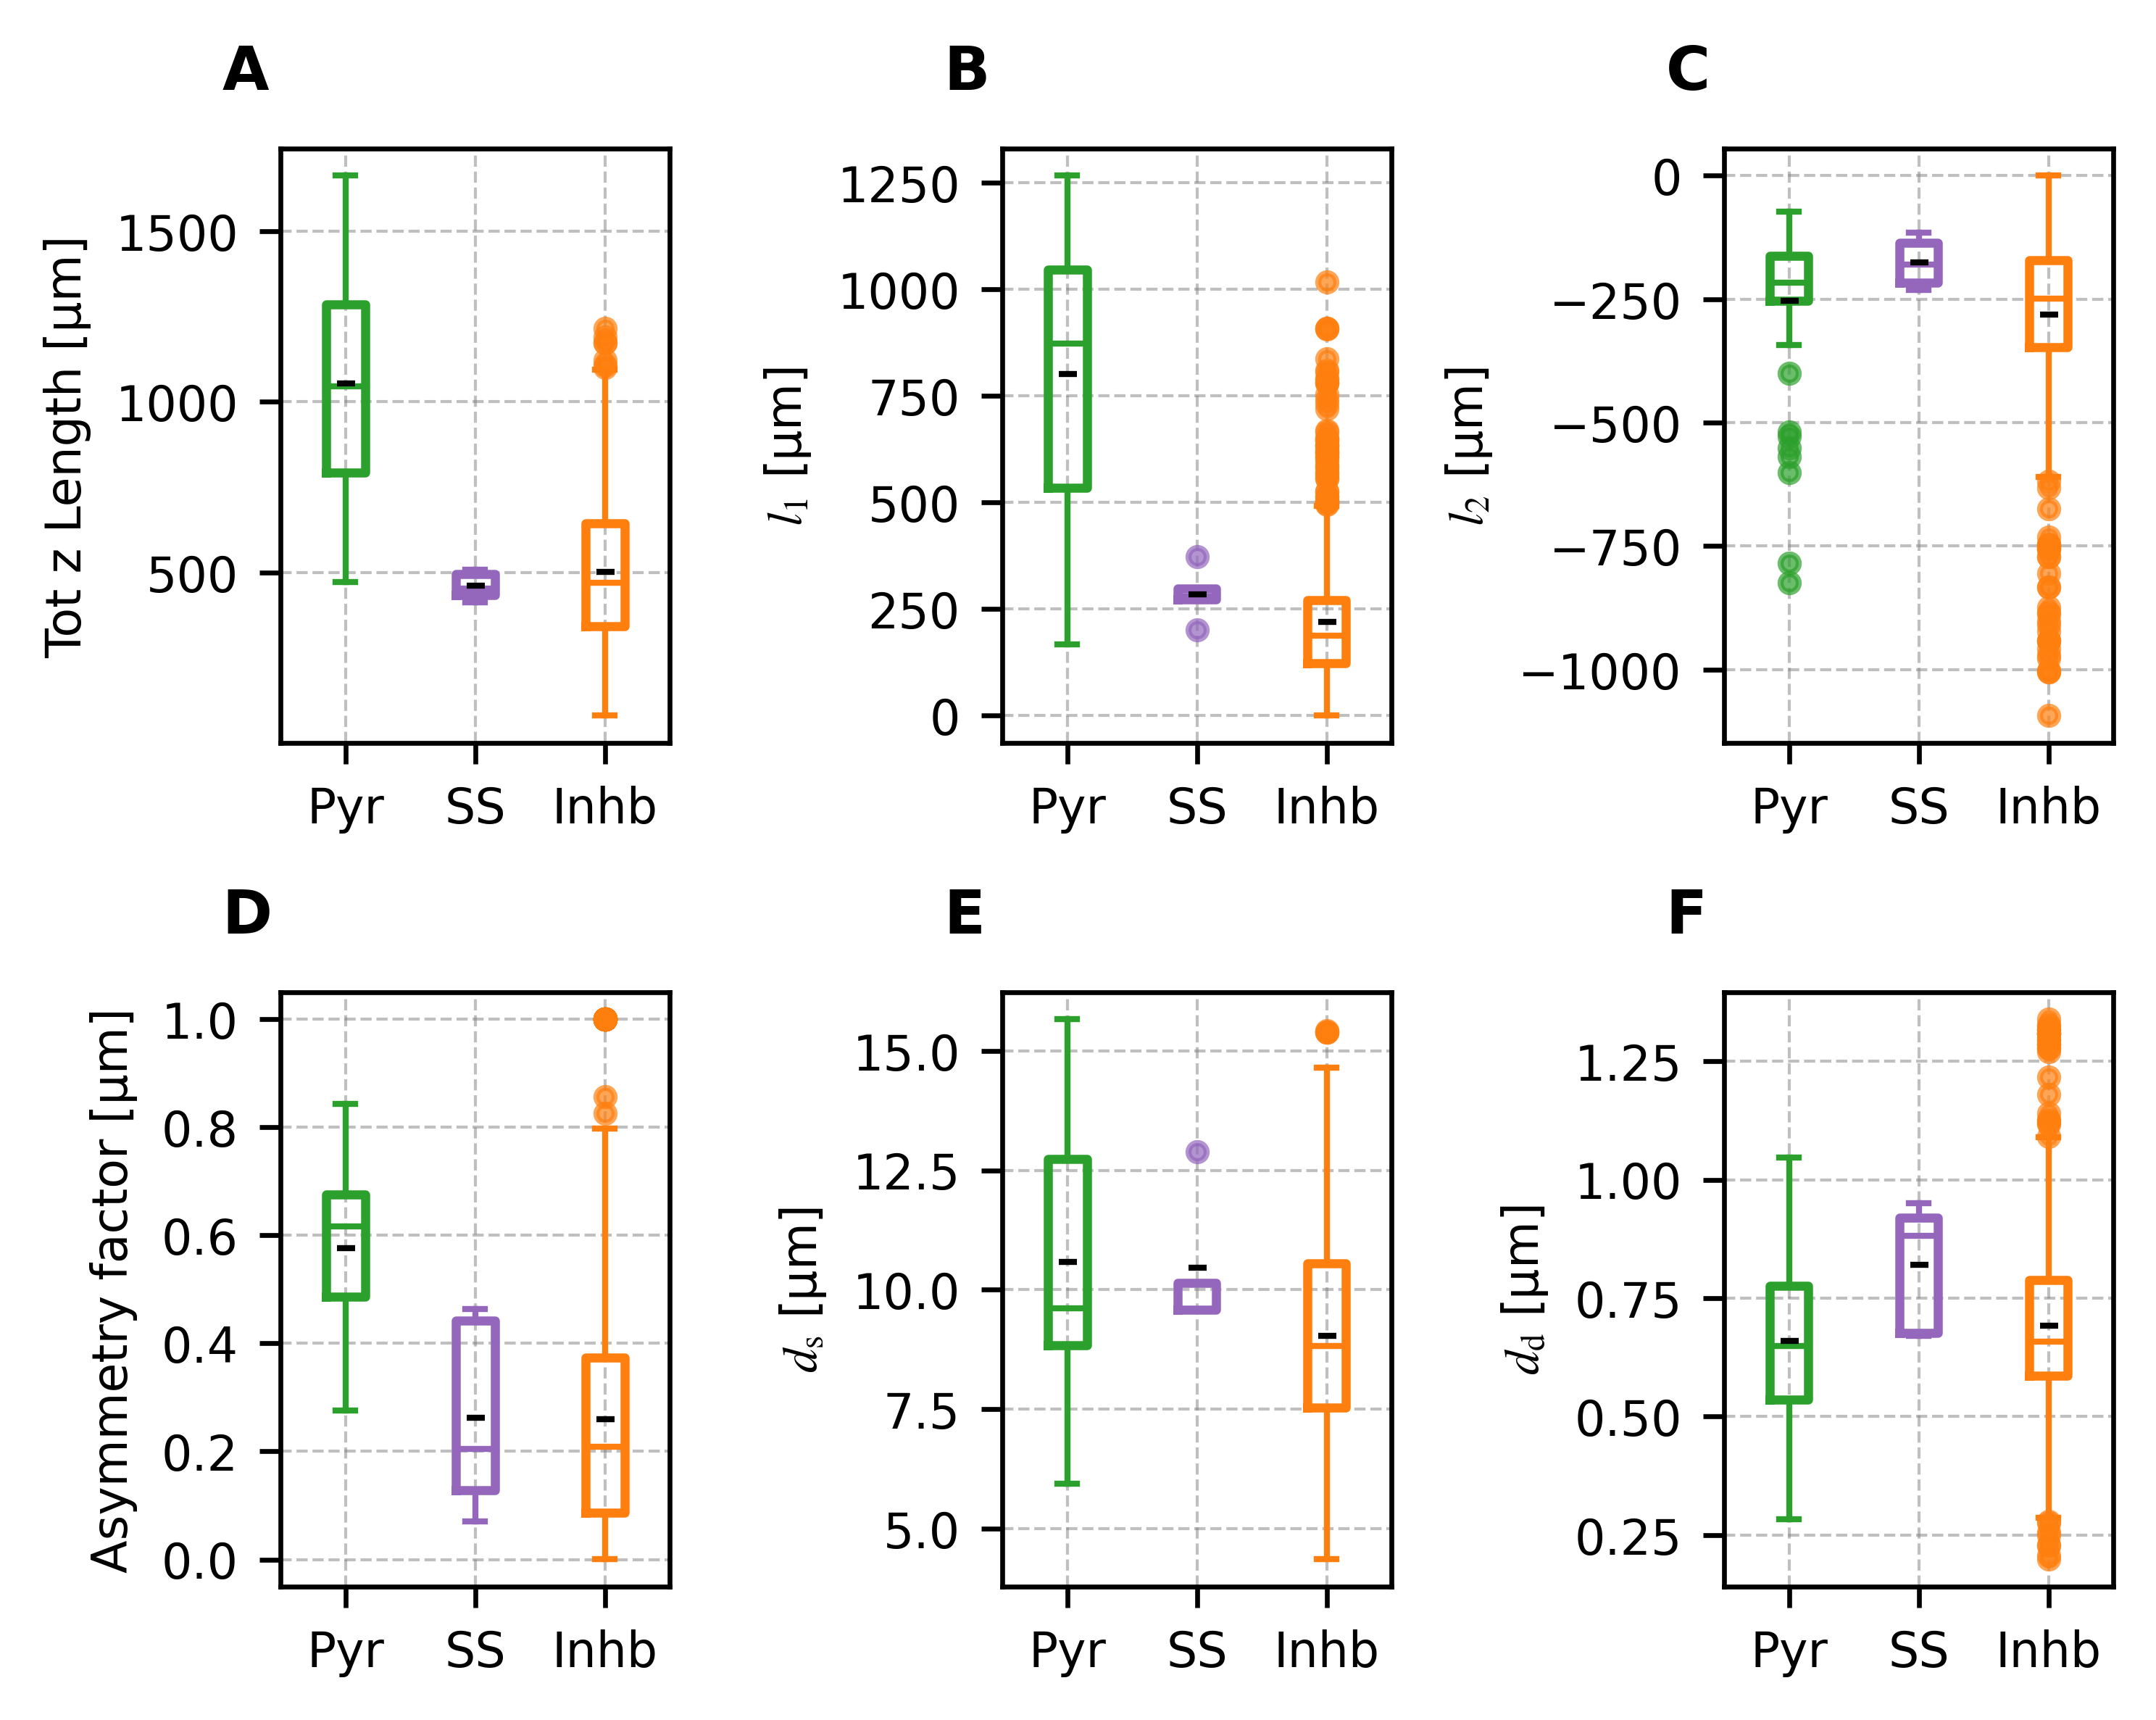

,Property,Pyramidal mean,Pyramidal median,Inhibitory mean,Inhibitory median
0,Tot z Length,1054.40,1045.92,501.78,469.90
1,$l_1$,800.22,872.88,220.33,188.03
2,$l_2$,-254.18,-216.20,-281.45,-248.97
3,Asymmetry factor,0.58,0.62,0.26,0.21
4,$d_\mathrm{s}$,10.58,9.61,9.03,8.83
5,$d_\mathrm{d}$,0.66,0.65,0.69,0.66


In [15]:
properties = ['total_len', 'upper_z_endpoint',  'bottom_z_endpoint', 'asymmetry_factor', 'soma_diam', 'avg_z_diam']
prop_names = {'total_len': 'Tot z Length', 
              'upper_z_endpoint': '$l_1$', 
              'bottom_z_endpoint': '$l_2$', 
              'asymmetry_factor': 'Asymmetry factor', 
              'len_difference': r'$\Delta l$',
              'soma_diam': r'$d_\mathrm{s}$',
              'avg_z_diam': r'$d_\mathrm{d}$'}

box_plot_morph_properties(vmem_amp_data, properties, prop_names)

dict_keys(['L23_MC_bAC217_5', 'L5_BP_bIR215_5', 'L23_NBC_bNAC219_5', 'L23_DBC_cACint209_3', 'L23_PC_cADpyr229_4', 'L6_NBC_cSTUT189_4', 'L23_NGC_bNAC219_4', 'L23_ChC_dNAC222_2', 'L4_MC_dNAC222_1', 'L6_NBC_bIR215_1', 'L23_PC_cADpyr229_5', 'L6_BTC_cNAC187_2', 'L6_MC_bSTUT213_2', 'L4_LBC_dSTUT214_3', 'L5_NGC_cSTUT189_4', 'L4_DBC_bIR215_1', 'L4_BP_bIR215_5', 'L5_LBC_dNAC222_5', 'L5_MC_cSTUT189_2', 'L23_BP_bAC217_2', 'L5_ChC_cACint209_4', 'L4_DBC_cIR216_2', 'L6_BTC_cACint209_5', 'L5_ChC_cNAC187_4', 'L5_DBC_cACint209_5', 'L4_NGC_cNAC187_4', 'L6_DBC_bAC217_4', 'L23_NGC_cACint209_1', 'L6_UTPC_cADpyr231_5', 'L5_LBC_cACint209_2', 'L1_NGC-SA_cNAC187_5', 'L1_DAC_cNAC187_1', 'L5_MC_cACint209_5', 'L6_BP_bIR215_1', 'L6_MC_bNAC219_1', 'L23_NBC_cACint209_2', 'L6_SBC_cACint209_1', 'L4_LBC_cACint209_5', 'L23_MC_dNAC222_2', 'L23_NBC_cIR216_1', 'L4_BTC_cNAC187_3', 'L6_SBC_bNAC219_1', 'L4_BTC_cNAC187_5', 'L23_LBC_cNAC187_1', 'L23_LBC_dNAC222_5', 'L1_DLAC_cNAC187_2', 'L6_MC_bIR215_3', 'L6_NGC_cNAC187_3', 'L4_